<a href="https://colab.research.google.com/github/aparna-2001/GATE_PPI/blob/main/pictures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

base_dir = '/content/drive/MyDrive/ppi_gnn'
graph_dir = f'{base_dir}/data/processed/graphs'
os.makedirs(f'{base_dir}/figures', exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch

def get_torch_version():
    return torch.__version__.split('+')[0]

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{get_torch_version()}+cpu.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{get_torch_version()}+cpu.html
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00


In [ ]:
#====== LOAD YOUR SAVED RESULTS ======

# 1. Load training history
history_df = pd.read_json(f'{base_dir}/data/processed/training_history_run2.json')
print(f"History loaded: {len(history_df)} epochs")

# 2. Load the final pairs file (for dataset composition figures)
pairs_final_aligned = pd.read_parquet(f'{base_dir}/data/labels/pairs_final_aligned.parquet')
print(f"Pairs loaded: {len(pairs_final_aligned):,}")


History loaded: 17 epochs
Pairs loaded: 5,016


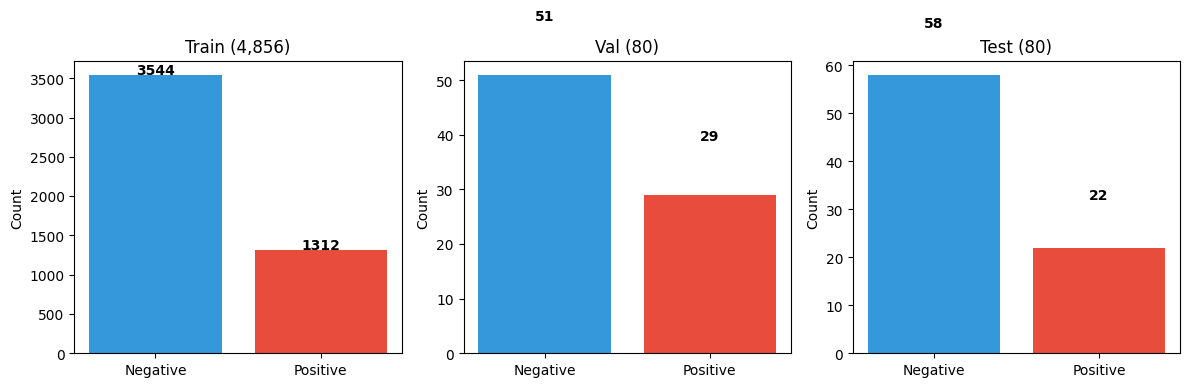

In [ ]:
# ====== FIGURE 2: Dataset Composition ======

train_df = pairs_final_aligned[pairs_final_aligned['split'] == 'train']
val_df = pairs_final_aligned[pairs_final_aligned['split'] == 'val']
test_df = pairs_final_aligned[pairs_final_aligned['split'] == 'test']

train_counts = train_df['label'].value_counts()
val_counts = val_df['label'].value_counts()
test_counts = test_df['label'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, counts, title in zip(axes, [train_counts, val_counts, test_counts],
                              ['Train (4,856)', 'Val (80)', 'Test (80)']):
    ax.bar(['Negative', 'Positive'], [counts.get(0, 0), counts.get(1, 0)],
           color=['#3498db', '#e74c3c'])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base_dir}/figures/dataset_composition.png', dpi=300)
plt.show()


In [ ]:
# ====== FIGURE 3: Structure Source Distribution ======

sources = []
for uid in pairs_final_aligned['protein1'].unique():
    g = torch.load(f'{graph_dir}/{uid}.pt', weights_only=False)
    sources.append(g.source)

source_counts = pd.Series(sources).value_counts()

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#3498db', '#e67e22']
plt.pie(source_counts.values, labels=source_counts.index,
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Protein Structure Source Distribution')
plt.tight_layout()
plt.savefig(f'{base_dir}/figures/structure_sources.png', dpi=300)
plt.show()


KeyboardInterrupt: 

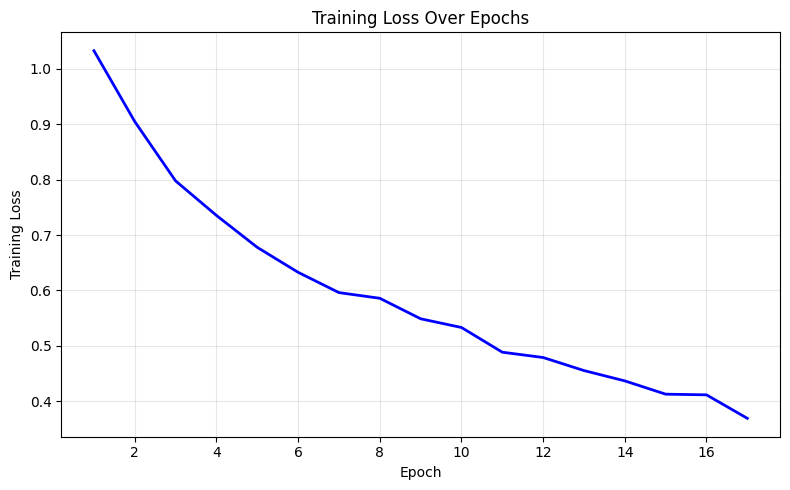

In [ ]:
# ====== FIGURE 4: Training Loss ======

plt.figure(figsize=(8, 5))
plt.plot(history_df['epoch'] + 1, history_df['train_loss'], 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{base_dir}/figures/training_loss.png', dpi=300)
plt.show()

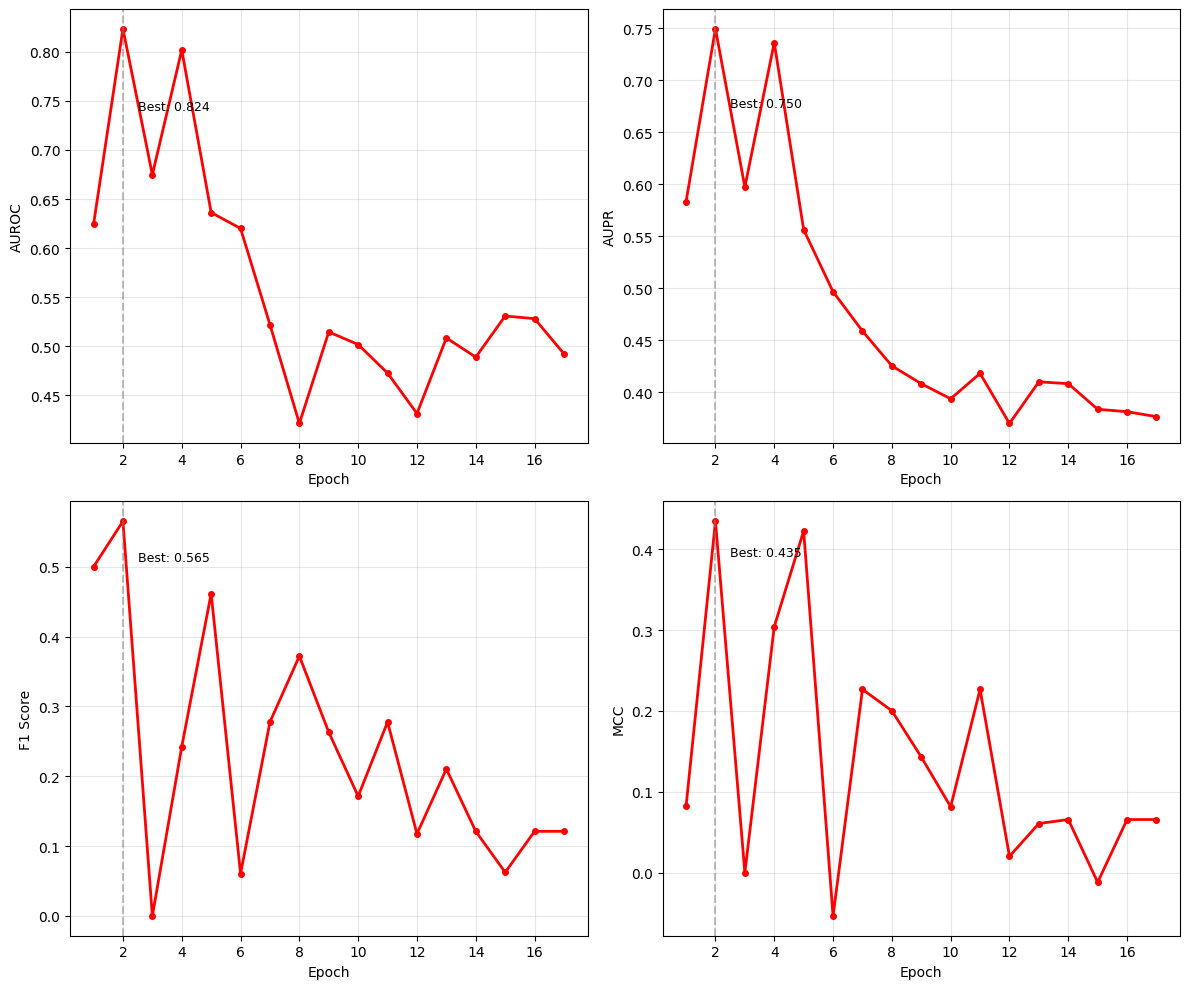

In [ ]:
# ====== FIGURE 5: Validation Metrics ======

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['auroc', 'aupr', 'f1', 'mcc']
titles = ['AUROC', 'AUPR', 'F1 Score', 'MCC']
for ax, metric, title in zip(axes.flatten(), metrics, titles):
    ax.plot(history_df['epoch'] + 1, history_df[metric], 'r-', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    best_idx = history_df[metric].idxmax()
    ax.axvline(x=best_idx + 1, color='gray', linestyle='--', alpha=0.5)
    ax.text(best_idx + 1 + 0.5, history_df[metric].max() * 0.9,
            f'Best: {history_df[metric].max():.3f}', fontsize=9)
plt.tight_layout()
plt.savefig(f'{base_dir}/figures/validation_metrics.png', dpi=300)
plt.show()



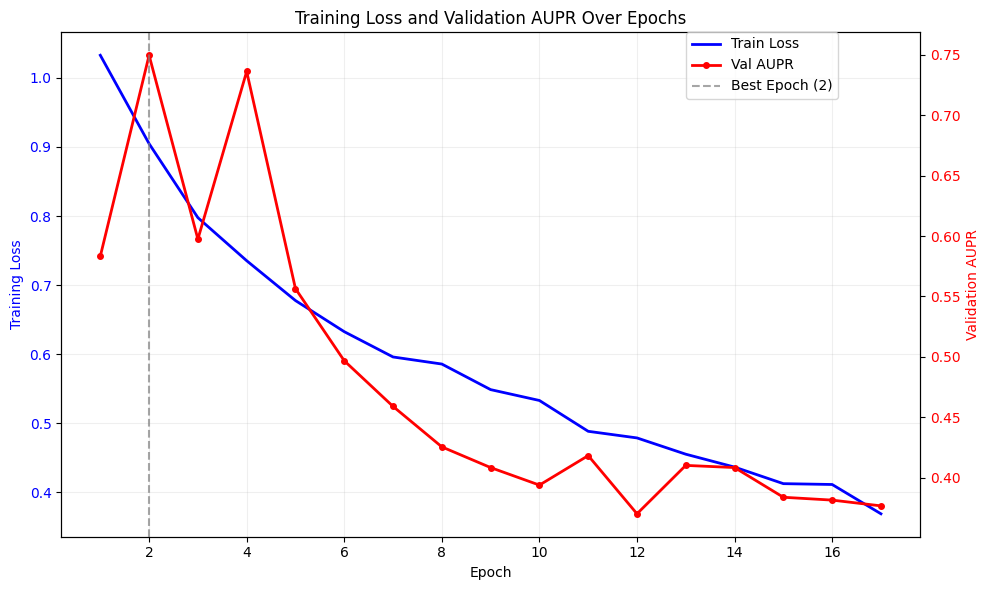

In [ ]:
# ====== FIGURE 6: Loss vs AUPR Combined ======

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color='blue')
ax1.plot(history_df['epoch'] + 1, history_df['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.2)
ax2 = ax1.twinx()
ax2.set_ylabel('Validation AUPR', color='red')
ax2.plot(history_df['epoch'] + 1, history_df['aupr'], 'r-', linewidth=2, marker='o', markersize=4, label='Val AUPR')
ax2.tick_params(axis='y', labelcolor='red')
best_idx = history_df['aupr'].idxmax()
ax2.axvline(x=best_idx + 1, color='gray', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_idx+1})')
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.95))
plt.title('Training Loss and Validation AUPR Over Epochs')
plt.tight_layout()
plt.savefig(f'{base_dir}/figures/loss_vs_aupr.png', dpi=300)
plt.show()



/tmp/ipykernel_2578/2208652427.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([low, mid, high], labels=['Low\n(<0.5)', 'Mid\n(0.5-0.7)', 'High\n(>0.7)'])


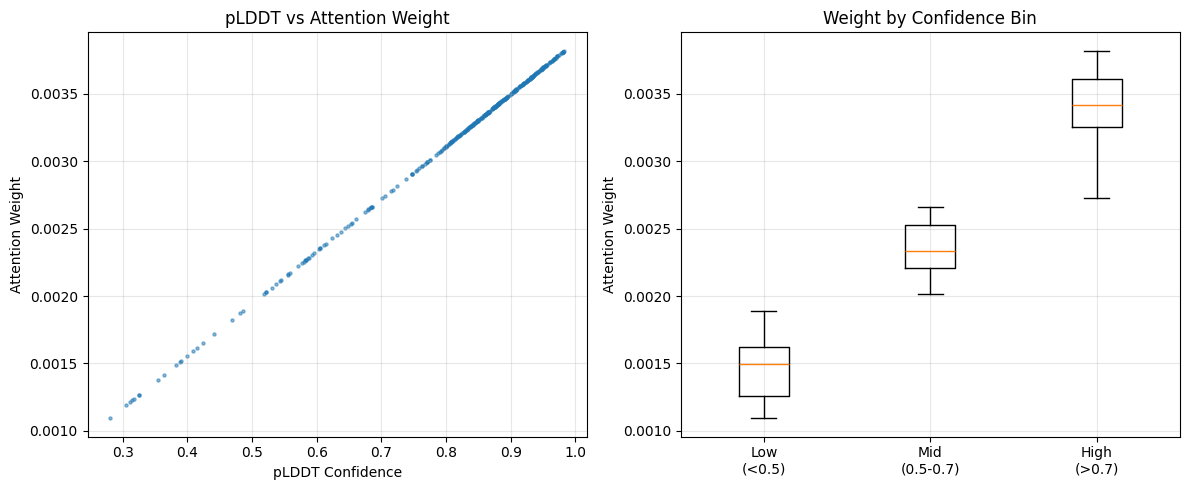

All figures saved to: /content/drive/MyDrive/ppi_gnn/figures/


In [ ]:
# ====== FIGURE 7: Confidence-Gated Pooling ======

# Load the model (you'll need this from your training notebook)
# If you saved best_model.pt:
# model = PPIModel().to('cpu')
# model.load_state_dict(torch.load(f'{base_dir}/data/processed/best_model.pt', map_location='cpu'))

# Find an AF2 protein with varying pLDDT
af2_uid = None
for uid in pairs_final_aligned['protein1'].unique():
    g = torch.load(f'{graph_dir}/{uid}.pt', weights_only=False)
    if g.source == 'AF2':
        af2_uid = uid
        break

if af2_uid:
    af2_graph = torch.load(f'{graph_dir}/{af2_uid}.pt', weights_only=False)
    plddt = af2_graph.x[:, 25]
    # For pooling weights, you need the model. If not available, use synthetic weights
    weights = torch.softmax(torch.log(plddt + 1e-8), dim=0)  # approximate

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.scatter(plddt.numpy(), weights.numpy(), alpha=0.5, s=5)
    ax1.set_xlabel('pLDDT Confidence')
    ax1.set_ylabel('Attention Weight')
    ax1.set_title(f'pLDDT vs Attention Weight')
    ax1.grid(True, alpha=0.3)

    low = weights[plddt < 0.5].numpy()
    mid = weights[(plddt >= 0.5) & (plddt < 0.7)].numpy()
    high = weights[plddt >= 0.7].numpy()
    ax2.boxplot([low, mid, high], labels=['Low\n(<0.5)', 'Mid\n(0.5-0.7)', 'High\n(>0.7)'])
    ax2.set_ylabel('Attention Weight')
    ax2.set_title('Weight by Confidence Bin')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{base_dir}/figures/confidence_gating.png', dpi=300)
    plt.show()

print("All figures saved to:", f'{base_dir}/figures/')


In [ ]:
print(f"Listing contents of: {base_dir}/data/processed/")
print(os.listdir(f'{base_dir}/data/processed/'))

Listing contents of: /content/drive/MyDrive/ppi_gnn/data/processed/
['dssp_results_step8c.pkl', 'aligned_sequences.pkl', 'esm_embeddings_step8d.pkl', 'final_node_features.pkl', 'all_edges.pkl', 'all_edge_features.pkl', 'graphs', 'node_features_step8b.pkl', 'best_model.pt', 'training_history_run2.json']


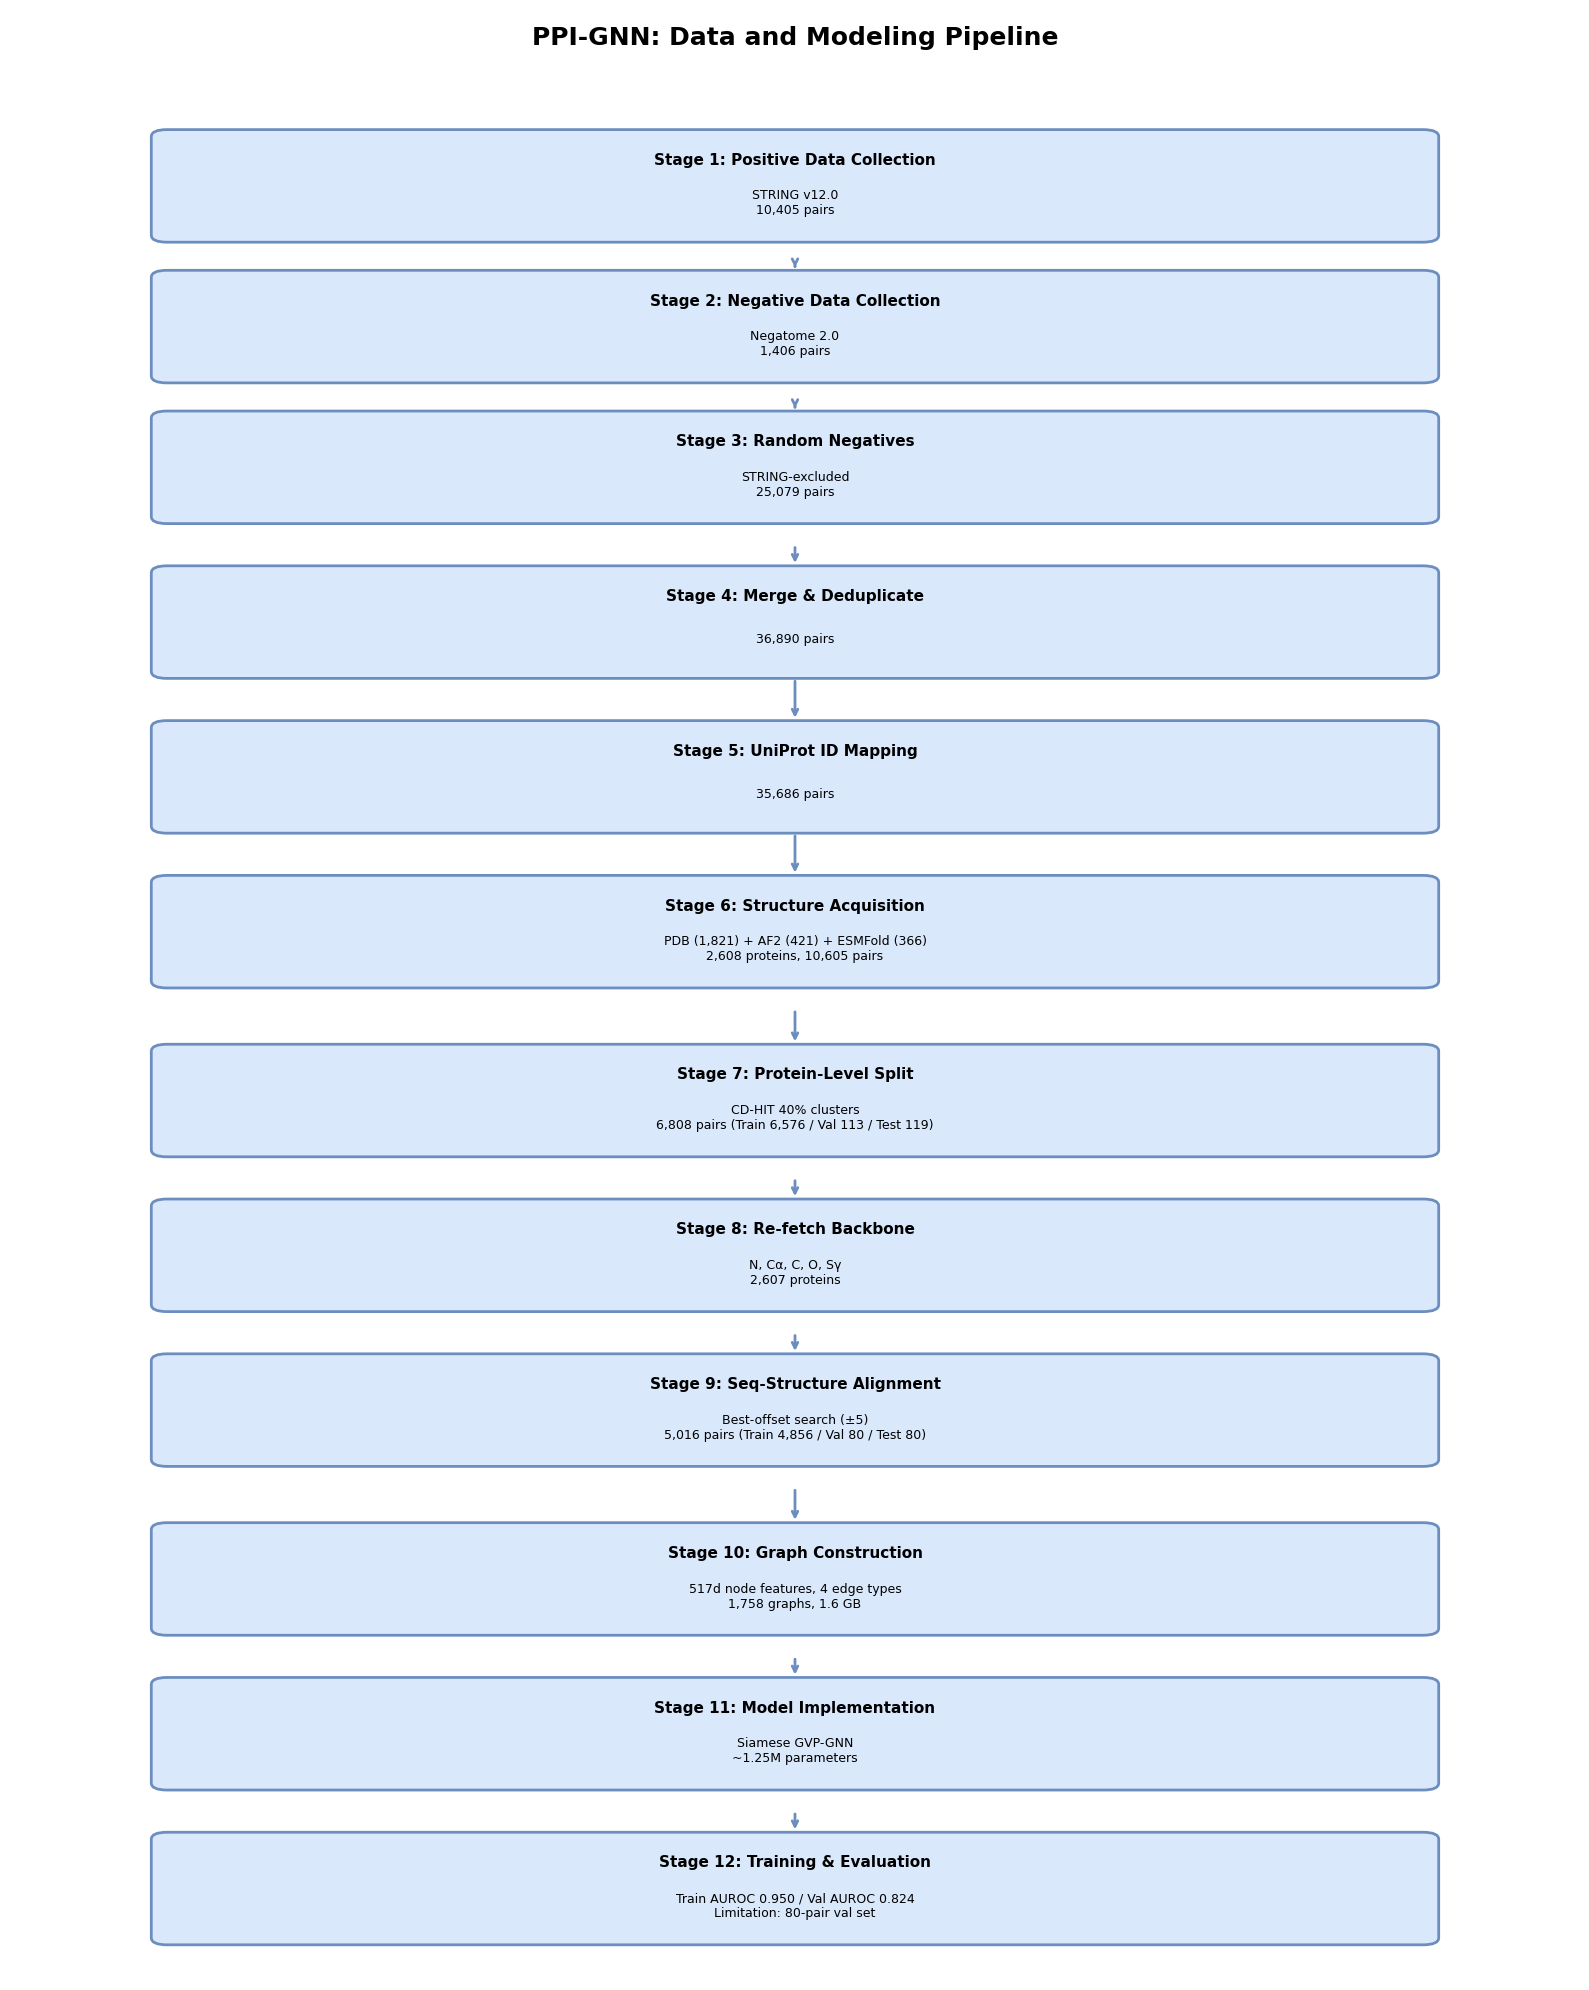

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(figsize=(16, 20))
ax.set_xlim(0, 10)
ax.set_ylim(0, 28)
ax.axis('off')

# Title
ax.text(5, 27.5, 'PPI-GNN: Data and Modeling Pipeline',
        fontsize=18, fontweight='bold', ha='center')

# Define stages with x, y positions (centered at x=5)
stages = [
    (5, 25.5, 'Stage 1: Positive Data Collection', 'STRING v12.0\n10,405 pairs'),
    (5, 23.5, 'Stage 2: Negative Data Collection', 'Negatome 2.0\n1,406 pairs'),
    (5, 21.5, 'Stage 3: Random Negatives', 'STRING-excluded\n25,079 pairs'),
    (5, 19.3, 'Stage 4: Merge & Deduplicate', '36,890 pairs'),
    (5, 17.1, 'Stage 5: UniProt ID Mapping', '35,686 pairs'),
    (5, 14.9, 'Stage 6: Structure Acquisition', 'PDB (1,821) + AF2 (421) + ESMFold (366)\n2,608 proteins, 10,605 pairs'),
    (5, 12.5, 'Stage 7: Protein-Level Split', 'CD-HIT 40% clusters\n6,808 pairs (Train 6,576 / Val 113 / Test 119)'),
    (5, 10.3, 'Stage 8: Re-fetch Backbone', 'N, Cα, C, O, Sγ\n2,607 proteins'),
    (5, 8.1, 'Stage 9: Seq-Structure Alignment', 'Best-offset search (±5)\n5,016 pairs (Train 4,856 / Val 80 / Test 80)'),
    (5, 5.7, 'Stage 10: Graph Construction', '517d node features, 4 edge types\n1,758 graphs, 1.6 GB'),
    (5, 3.5, 'Stage 11: Model Implementation', 'Siamese GVP-GNN\n~1.25M parameters'),
    (5, 1.3, 'Stage 12: Training & Evaluation', 'Train AUROC 0.950 / Val AUROC 0.824\nLimitation: 80-pair val set'),
]

box_width = 8
box_height = 1.4

for x, y, title, subtitle in stages:
    # Box
    rect = FancyBboxPatch((x - box_width/2, y - box_height/2),
                           box_width, box_height,
                           boxstyle="round,pad=0.1",
                           facecolor='#DAE8FC', edgecolor='#6C8EBF', linewidth=2)
    ax.add_patch(rect)
    # Title
    ax.text(x, y + 0.3, title, fontsize=11, fontweight='bold', ha='center')
    # Subtitle
    ax.text(x, y - 0.25, subtitle, fontsize=9, ha='center', va='center')

# Arrows between stages
for i in range(len(stages)-1):
    x1, y1 = stages[i][0], stages[i][1] - stages[i][3].count('\n') * 0.3 - 0.8
    x2, y2 = stages[i+1][0], stages[i+1][1] + 0.8
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#6C8EBF', lw=2))

plt.tight_layout()
plt.savefig('pipeline_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()